# Bank Loan Risk Analysis 
### Phase 2: EDA and Feature Engineering

- This notebook performs exploratory data analysis and engineers new features for the cleaned bank loan dataset.

- Visuals are generated to help discover key findings and patterns.

#### Business context and goal

- The goal of this project is to help The Bank understand the risk and performance of its consumer lending portfolio so it can make better decisions on credit policies, pricing, and marketing strategy. AGE Analytics aims to build a modeling pipeline that can estimate the default risk of each loan applicant and identify high‑risk segments before loans are approved. In this phase, we analyze the cleaned dataset, explore drivers of default, and engineer modeling‑ready features that will feed into the predictive model in the next notebook.

#### Role of this notebook in the pipeline

- This Phase 2 notebook takes the cleaned, de‑duplicated loan file from Phase 1 as input and produces an engineered feature set plus EDA findings as output. These outputs will be saved to the project’s processed data directory and used as the primary input for the modeling and evaluation notebooks in later phases

In [4]:
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 


sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

In [5]:

PROJECT_ROOT = Path.cwd().parents[1]

DATA_DIR = PROJECT_ROOT / "data"
INTERIM_DIR = DATA_DIR / "interim"
PROCESSED_DIR = DATA_DIR / "processed"

MODEL_INPUT = INTERIM_DIR / "bank_loan_data_v2_model.csv"
ENGINEERED_OUTPUT = PROCESSED_DIR / "bank_loan_data_engineered.csv"

print("Project root:", PROJECT_ROOT)
print("Model input:", MODEL_INPUT)
print("Engineered output:", ENGINEERED_OUTPUT)

df = pd.read_csv(MODEL_INPUT)

# Format for display
numeric_cols = df.select_dtypes(include=[np.number]).columns
format_dict = {col: '{:.1f}' for col in numeric_cols}
format_dict['income'] = '{:.0f}'

df.head().style.format(format_dict)

Project root: /Users/macbook/projects/data-science/bank-loan-risk
Model input: /Users/macbook/projects/data-science/bank-loan-risk/data/interim/bank_loan_data_v2_model.csv
Engineered output: /Users/macbook/projects/data-science/bank-loan-risk/data/processed/bank_loan_data_engineered.csv


,age,gender,education,income,employment_experience_length,home_ownership,loan_amount,loan_purpose,loan_interest_rate,loan_percent_to_income,credit_history_length,credit_score,previous_loan_default,loan_repaid,age_outlier_rule,income_outlier_rule,experience_outlier_rule,credit_history_outlier_rule,age_outlier_iqr,income_outlier_iqr,loan_amount_outlier_iqr,loan_interest_rate_outlier_iqr,loan_percent_to_income_outlier_iqr,credit_history_length_outlier_iqr,credit_score_outlier_iqr,credit_score_outlier_z,loan_interest_rate_outlier_z,age_outlier_z,income_capped,loan_amount_capped,loan_percent_to_income_capped
0,22.0,female,Master,71948,0.0,RENT,35000.0,PERSONAL,16.0,0.5,3.0,561.0,No,1.0,False,False,False,False,False,False,True,False,True,False,False,False,False,False,71948.0,28393.1,0.4
1,21.0,female,High School,12282,0.0,OWN,1000.0,EDUCATION,11.1,0.1,2.0,504.0,Yes,0.0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,12282.0,1000.0,0.1
2,25.0,female,High School,12438,3.0,MORTGAGE,5500.0,MEDICAL,12.9,0.4,3.0,635.0,No,1.0,False,False,False,False,False,False,False,False,True,False,False,False,False,False,12438.0,5500.0,0.4
3,23.0,female,Bachelor,79753,0.0,RENT,35000.0,MEDICAL,15.2,0.4,2.0,675.0,No,1.0,False,False,False,False,False,False,True,False,True,False,False,False,False,False,79753.0,28393.1,0.4
4,24.0,male,Master,66135,1.0,RENT,35000.0,MEDICAL,14.3,0.5,4.0,586.0,No,1.0,False,False,False,False,False,False,True,False,True,False,False,False,False,False,66135.0,28393.1,0.4


In [6]:
print("Shape:", df.shape)
df.dtypes


Shape: (44992, 31)


age                                   float64
gender                                 object
education                              object
income                                float64
employment_experience_length            int64
home_ownership                         object
loan_amount                           float64
loan_purpose                           object
loan_interest_rate                    float64
loan_percent_to_income                float64
credit_history_length                 float64
credit_score                            int64
previous_loan_default                  object
loan_repaid                             int64
age_outlier_rule                         bool
income_outlier_rule                      bool
experience_outlier_rule                  bool
credit_history_outlier_rule              bool
age_outlier_iqr                          bool
income_outlier_iqr                       bool
loan_amount_outlier_iqr                  bool
loan_interest_rate_outlier_iqr    

In [7]:
num_cols = [
    "age",
    "income",
    "income_capped",
    "employment_experience_length",
    "loan_amount",
    "loan_amount_capped",
    "loan_interest_rate",
    "loan_percent_to_income",
    "loan_percent_to_income_capped",
    "credit_history_length",
    "credit_score",
]

In [8]:
numeric_profile = df[num_cols].describe().T
display(numeric_profile)


,count,mean,std,min,25%,50%,75%,max
age,"44,992.000",27.747,5.902,20.000,24.000,26.000,30.000,84.000
income,"44,992.000","79,909.563","63,322.394","8,000.000","47,197.250","67,046.000","95,779.000","2,448,661.000"
income_capped,"44,992.000","78,023.233","45,420.165","8,000.000","47,197.250","67,046.000","95,779.000","271,267.580"
employment_experience_length,"44,992.000",5.393,5.918,0.000,1.000,4.000,8.000,62.000
loan_amount,"44,992.000","9,583.245","6,314.856",500.000,"5,000.000","8,000.000","12,237.250","35,000.000"
loan_amount_capped,"44,992.000","9,538.802","6,160.127",500.000,"5,000.000","8,000.000","12,237.250","28,393.060"
loan_interest_rate,"44,992.000",11.006,2.979,5.420,8.590,11.010,12.990,20.000
loan_percent_to_income,"44,992.000",0.140,0.087,0.000,0.070,0.120,0.190,0.660
loan_percent_to_income_capped,"44,992.000",0.139,0.086,0.000,0.070,0.120,0.190,0.400
credit_history_length,"44,992.000",5.866,3.876,2.000,3.000,4.000,8.000,30.000


## Target distribution

We first inspect the distribution of the target `loan_repaid` to understand class balance
and create a convenient `loan_defaulted` label for interpretation.

,Loan Repaid,Proportion
0,0,0.778
1,1,0.222


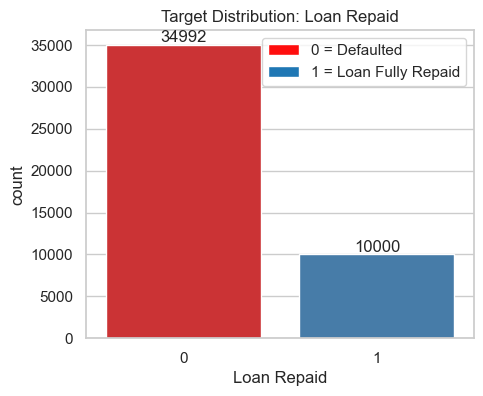

In [9]:
from matplotlib.patches import Patch



# If 1 = repaid, 0 = not repaid
target_summary = (
    df["loan_repaid"]
    .value_counts(normalize=True)
    .rename_axis("Loan Repaid")
    .reset_index(name="Proportion")
)

display(target_summary)

plt.figure(figsize=(5, 4))
ax = sns.countplot(data=df, x="loan_repaid", hue="loan_repaid", palette="Set1", legend=False)
plt.title("Target Distribution: Loan Repaid")
plt.xlabel("Loan Repaid")

# Add count labels on top of bars
for container in ax.containers:
    ax.bar_label(container)

# Add custom legend
legend_elements = [Patch(facecolor="#FF0E0E", label='0 = Defaulted'),
                   Patch(facecolor='#1F77B4', label='1 = Loan Fully Repaid')]
ax.legend(handles=legend_elements, loc='upper right')

plt.show()

# Optional helper: default indicator
df["default_flag"] = 1 - df["loan_repaid"]

### Target Variable Distribution FIndings 

- 34,992 Borrowers(~78%) defaulted. (loan_repaid = '0')
- 10,000 Borrowers(~22%) repaid. (loan_repaid = '1')
- We have moderate to highly imbalanced dataset(loan_repaid). The majority class being "defaults", we will need to keep this in mind when modeling (class weights, resampling or threshold tuning)

In [10]:
# Count for each type of loan purpose

df['loan_purpose'].value_counts ()

loan_purpose
EDUCATION            9151
MEDICAL              8547
VENTURE              7815
PERSONAL             7551
DEBTCONSOLIDATION    7145
HOMEIMPROVEMENT      4783
Name: count, dtype: int64

## Univariate Analysis – Numeric Features
* Feature Distribution and Outliers
* Inspect the distribution for:
    age, income, loan amount, DTI, credit score, etc.

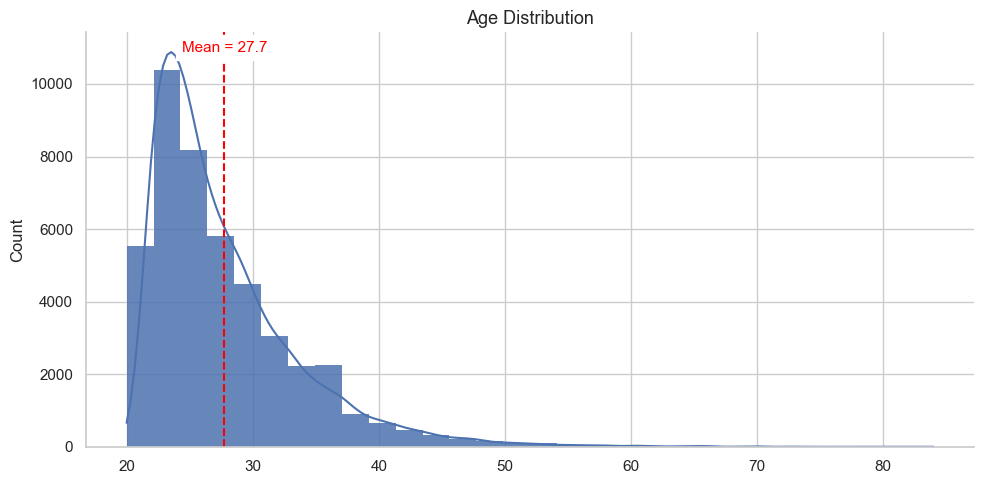

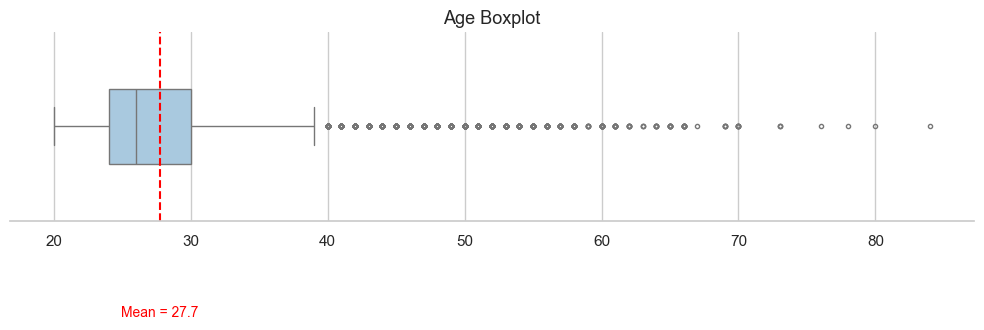

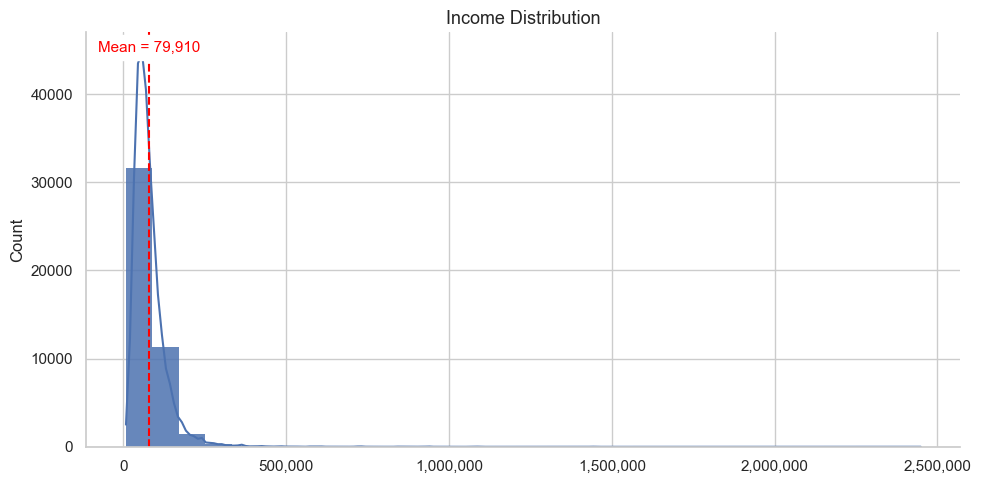

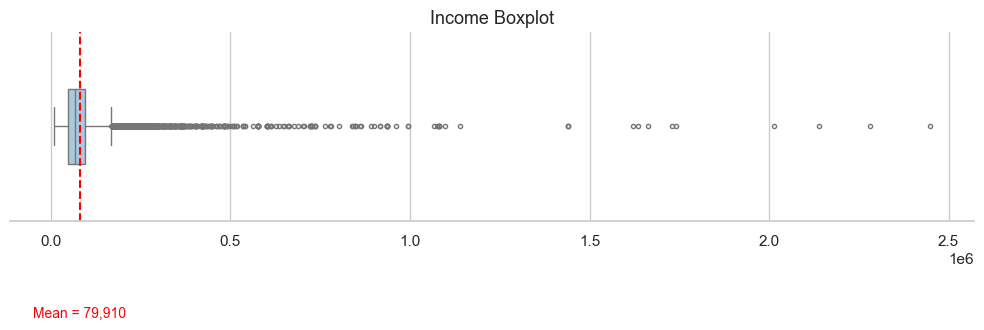

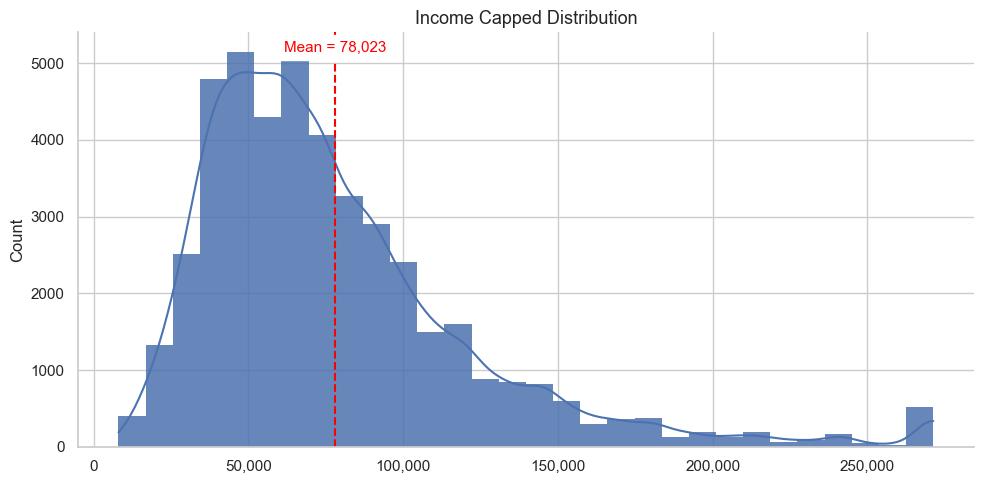

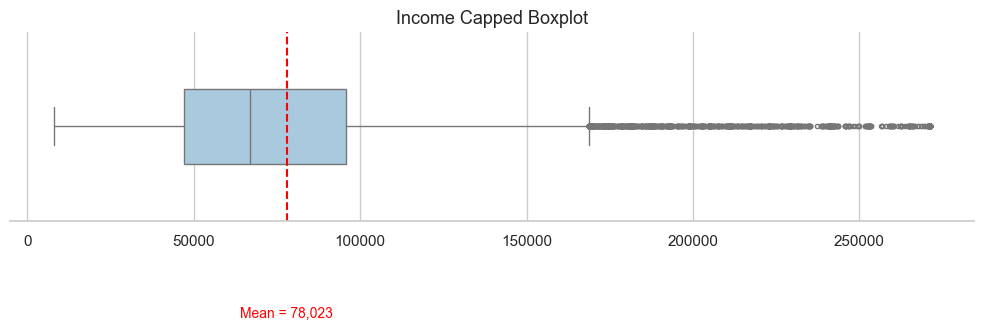

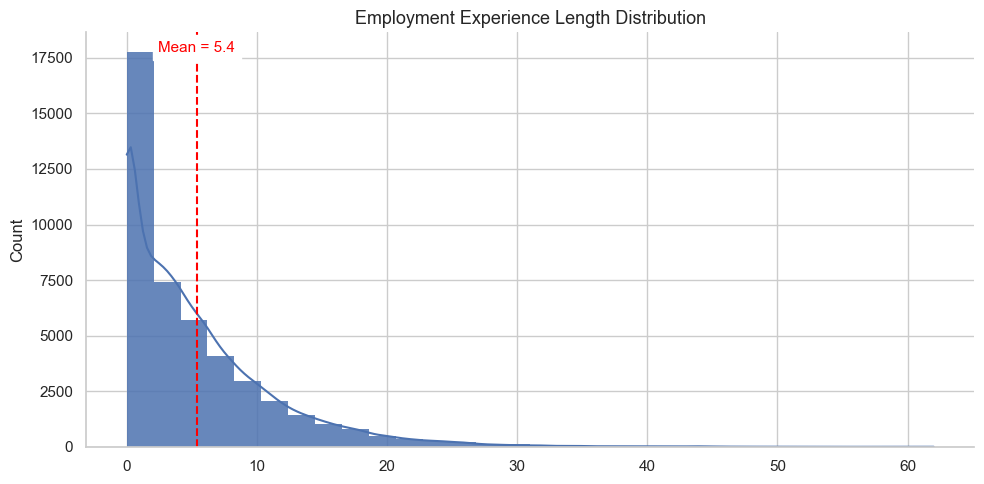

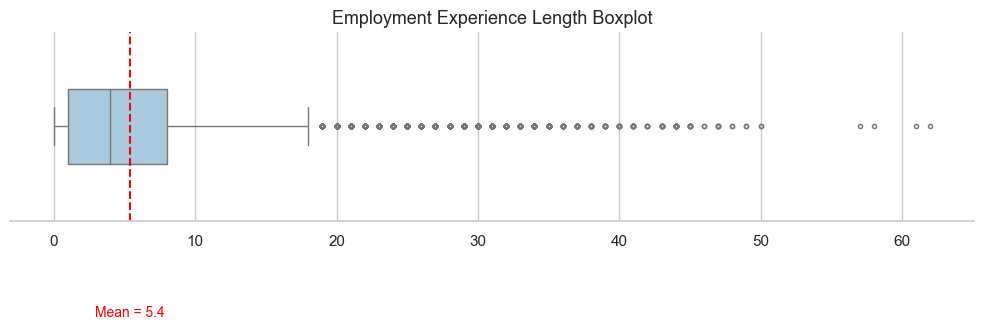

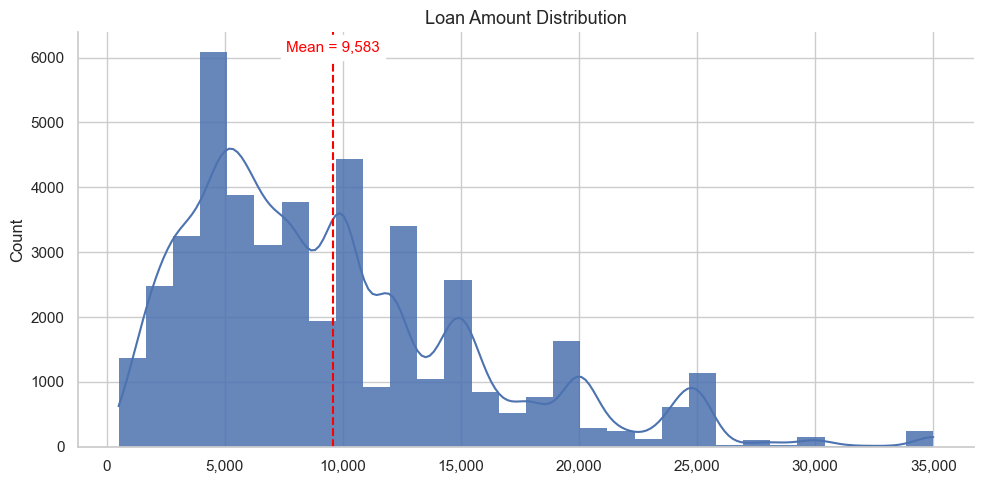

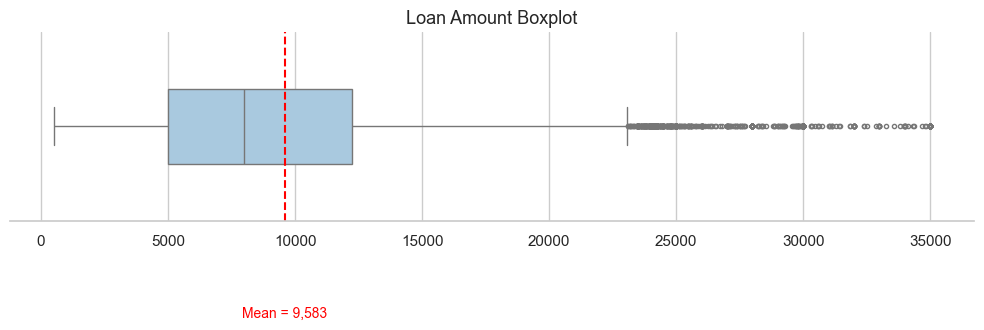

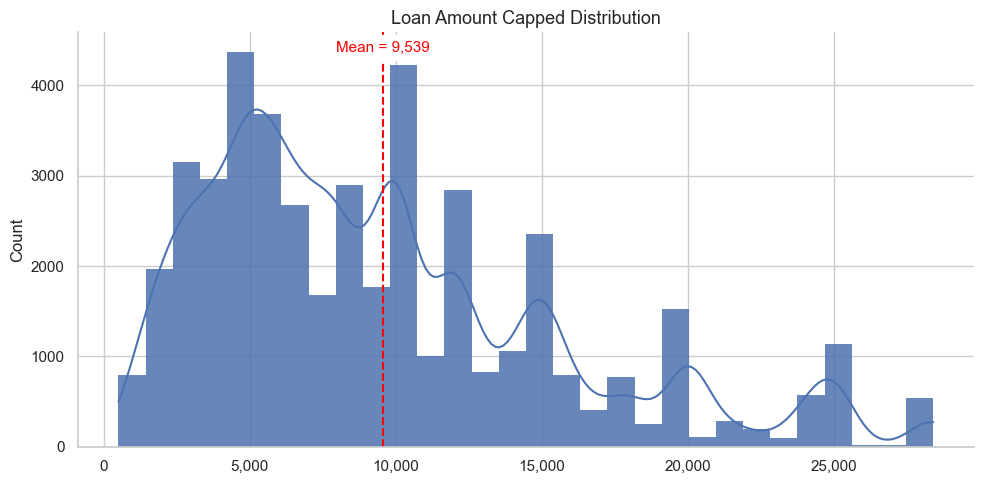

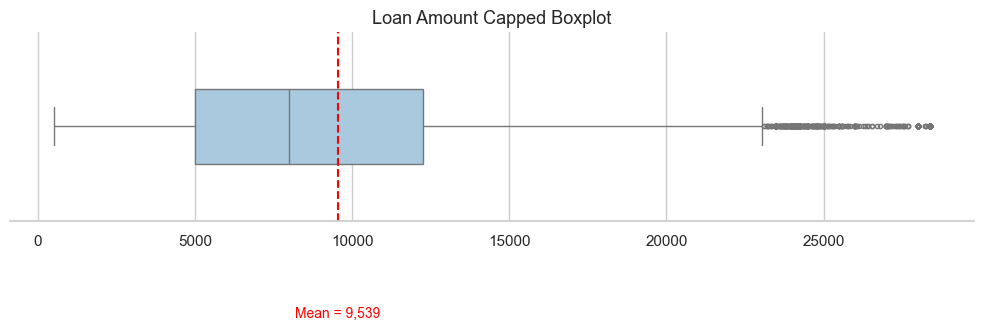

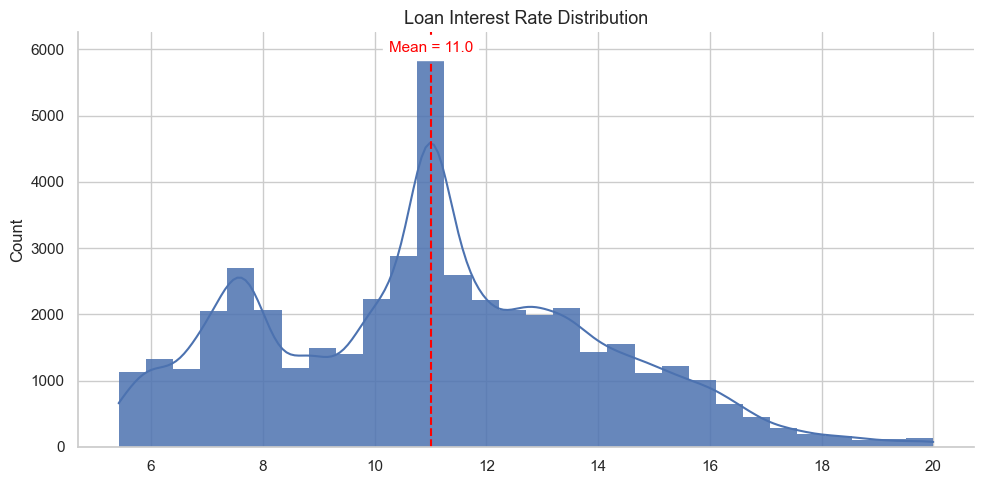

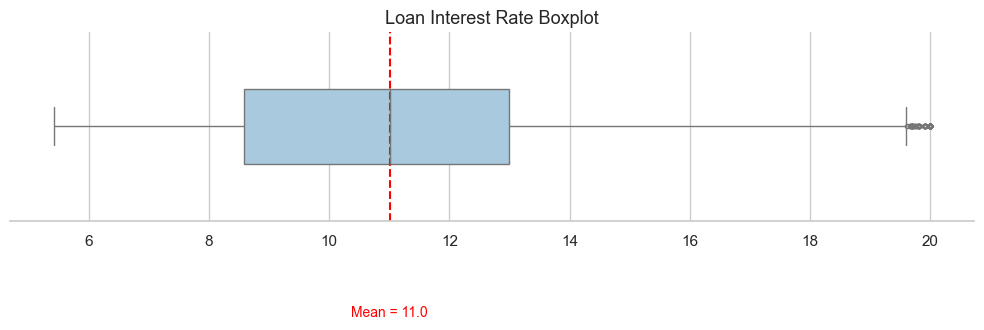

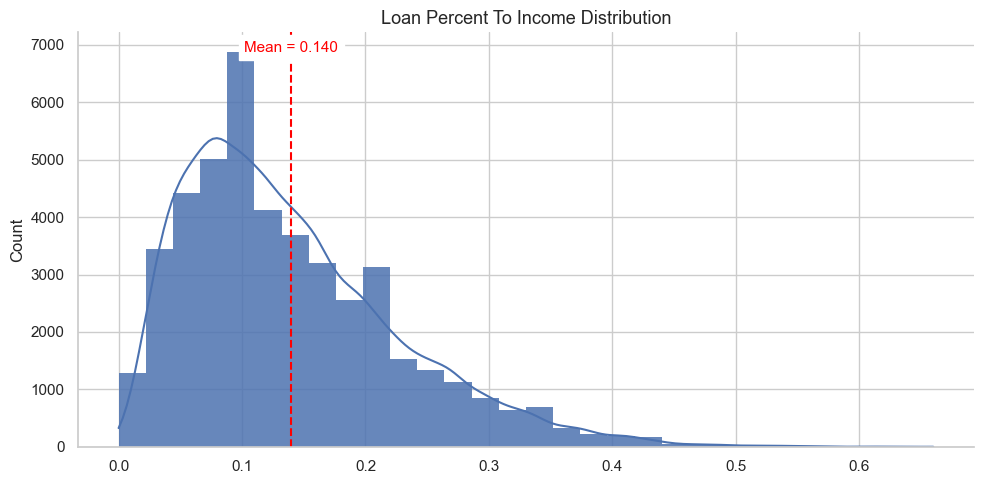

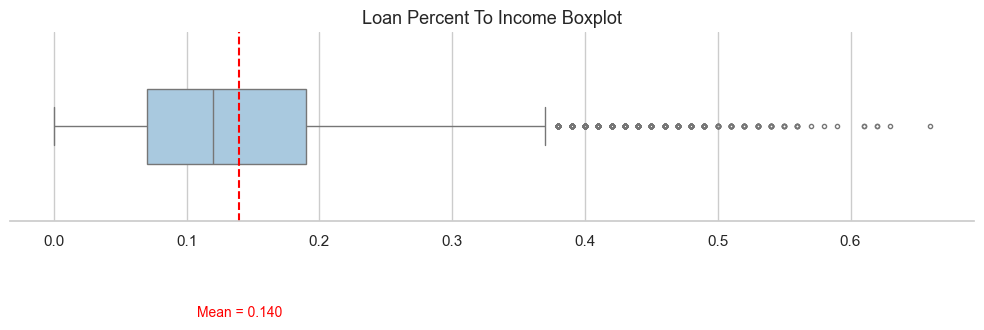

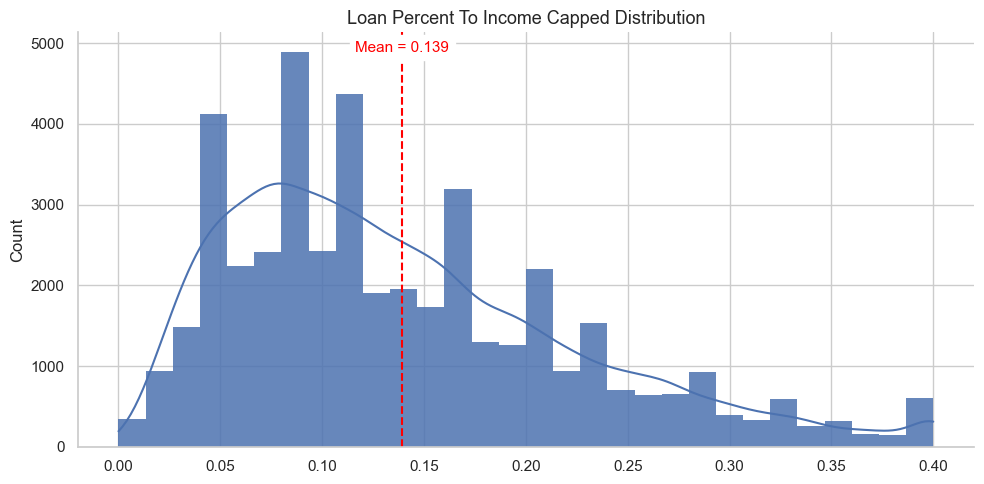

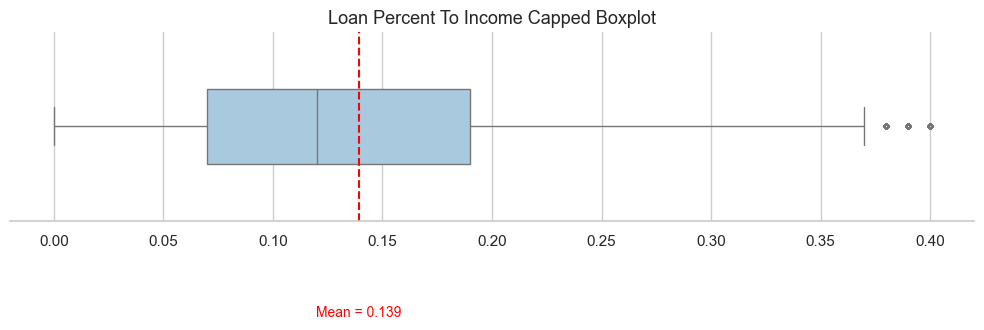

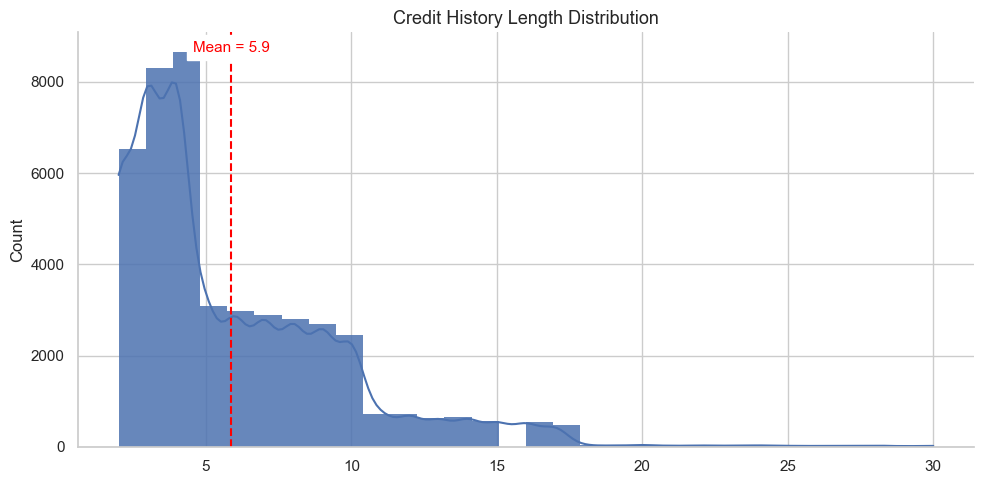

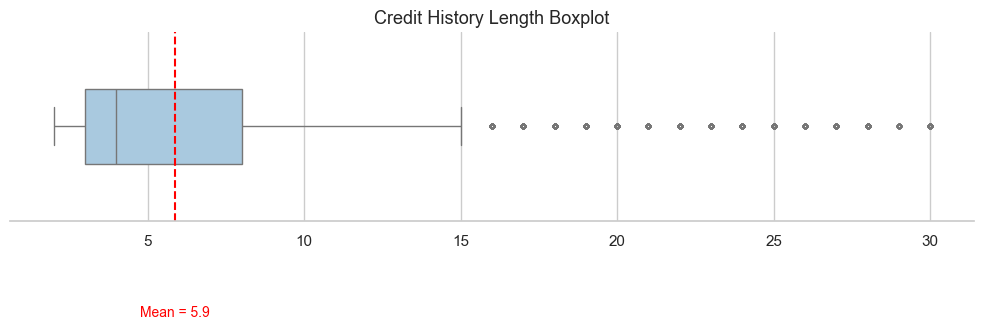

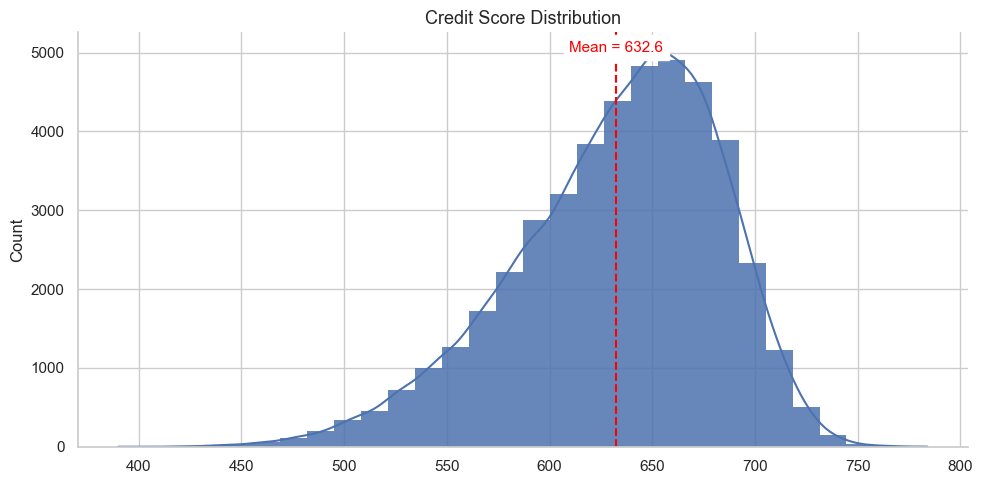

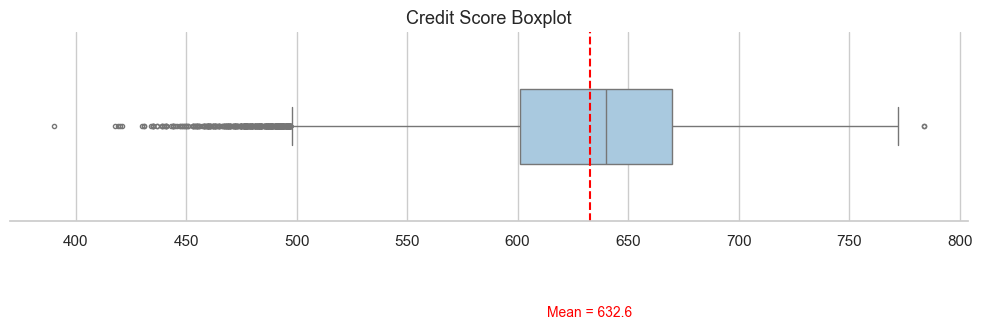

In [11]:
from matplotlib.ticker import FuncFormatter

def thousands(x, pos):
    return f"{int(x):,}"

for col in num_cols:
    mean_val = df[col].mean()
    if col in ["income", "income_capped", "loan_amount", "loan_amount_capped"]:
        mean_label = f"Mean = {mean_val:,.0f}"
    elif col in ["loan_percent_to_income", "loan_percent_to_income_capped"]:
        mean_label = f"Mean = {mean_val:.3f}"
    else:
        mean_label = f"Mean = {mean_val:.1f}"

    # -------------------------
    # Distribution plot
    # -------------------------
    fig, ax = plt.subplots(figsize=(10, 5))

    ax = sns.histplot(
        df[col],
        bins=30,
        kde=True,
        color="#4C72B0",
        edgecolor="none",
        alpha=0.85,
        ax=ax,
    )

    if col in ["income", "income_capped", "loan_amount", "loan_amount_capped"]:
        ax.xaxis.set_major_formatter(FuncFormatter(thousands))

    ax.axvline(mean_val, color="red", linestyle="--", linewidth=1.5)
    ymax = ax.get_ylim()[1]
    ax.text(
        mean_val,
        ymax * 0.98,  # Shifted higher to the top
        mean_label,
        color="red",
        fontsize=11,
        ha="center",
        va="top",
        backgroundcolor="white",
    )

    for line in ax.lines:
        line.set_linewidth(1.5)

    ax.set_title(f"{col.replace('_', ' ').title()} Distribution", fontsize=13)
    ax.set_xlabel("")
    ax.set_ylabel("Count")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()
    plt.show()

    # -------------------------
    # Boxplot
    # -------------------------
    fig, ax = plt.subplots(figsize=(10, 4))  # Elongated height

    sns.boxplot(
        x=df[col],
        color="#A0CBE8",
        width=0.4,
        fliersize=3,
        ax=ax,
    )

    ax.axvline(mean_val, color="red", linestyle="--", linewidth=1.5)
    ax.text(
        mean_val,
        0.95,  # Shifted to the top
        mean_label,
        color="red",
        fontsize=10,
        ha="center",
        va="top",
        backgroundcolor="white",
    )

    ax.set_title(f"{col.replace('_', ' ').title()} Boxplot", fontsize=13)
    ax.set_xlabel("")
    ax.set_yticks([])
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)

    plt.tight_layout()
    plt.show()

# Numeric Features Distribution and Outliers: 

### Descriptive Findings 
* Ages are concentrated in the early to mid‑20s, with a sparse right tail extending into the 80s. The distribution is right‑skewed with most borrowers in a relatively young segment.

* Income is strongly right‑skewed, with many low‑to‑moderate earners and a long tail of high‑income borrowers. A small number of applicants have substantially higher incomes than the majority.

* Loan amounts are right‑skewed and appear multimodal, with several peaks that likely correspond to different loan tiers or product types. Most loans are relatively small, with fewer large‑balance loans.

* Employment length is heavily concentrated between 0–1 year and tapers off gradually up to around 60 years. This suggests many new or early‑career borrowers and relatively fewer with very long employment histories.

* Loan interest rates have a dominant peak around 11% and a secondary cluster between roughly 7–8%, with a long right tail toward higher rates. The distribution is right‑skewed and multimodal rather than a single bell‑shaped curve.

* The loan‑to‑income ratio is mostly concentrated between about 0.10 and 0.13, with a right‑skewed tail extending toward higher leverage levels. After capping, the capped distribution shows multiple peaks throughout the range up to roughly 0.40.

* Credit history length is mildly right‑skewed, with most borrowers clustered around 3–4 years of history. Very long histories are less common but present in the right tail.

* Credit scores are strongly left‑skewed, with most applicants clustered between roughly 600–700. Very low scores are relatively rare, which is consistent with typical lending guidelines.

### Modeling Implications 
* Age : Keep raw age and consider binning into broad age bands (e.g., 18–25, 26–35, 36–50, 50+) to capture non‑linear effects and make results easier to interpret.

* Income: Apply a high‑percentile cap to extreme incomes and create a log1p(income) feature to reduce the influence of very high earners and stabilize relationships in linear/logistic models.

* Loan Amount: Cap very large loan amounts and add a log1p(loan_amount) feature. Consider interacting loan amount with loan type or term, since the multimodality suggests different underlying products.

* Employment Experience Length: Consider both a capped continuous feature and coarse bins (e.g., 0 years, 1–3, 4–7, 8–15, 16+) to represent early‑career vs experienced borrowers. A log1p transform can be used if linear models struggle with the heavy right tail.

* Loan Interest Rate: Treat interest rate as a continuous feature but be aware of multimodality; you may also add bins or indicators aligned with pricing tiers (e.g., <8%, 8–10%, 10–12%, >12%) to capture non‑linear effects.

* Loan Percent to Income: Cap extreme loan‑to‑income ratios and keep the capped raw ratio for interpretability. Optionally create a log1p version for models that assume more linear relationships.

* Credit History Length: Use the raw (possibly capped) credit history length as a primary feature; transformation is likely optional. You can add simple bins (e.g., <2 years, 2–5, >5) if you want more interpretable risk buckets.

* Credit Score: Use the raw credit score and optionally create categorical risk bands (e.g., <580, 580–629, 630–679, 680–739, ≥740) to align with lending practice and support business interpretation.

# Bivariate Analysis for Numeric Features 

In [12]:
# Group by loan_purpose and compute default rate

default_rate_by_purpose = (
    df.groupby("loan_purpose")["loan_repaid"]
      .mean()                             # repayment rate per purpose
      .rsub(1)                            # 1 - repayment rate = default rate
      .rename("default_rate")
      .sort_values(ascending=False)       # sort by highest default rate
      .reset_index()
)

default_rate_by_purpose.head()

,loan_purpose,default_rate
0,VENTURE,0.856
1,EDUCATION,0.830
2,PERSONAL,0.799
3,HOMEIMPROVEMENT,0.737
4,MEDICAL,0.722


### High Default rate regardless of loan purpose. Venture Capital Loans and Educational Loans have the highest default rate 

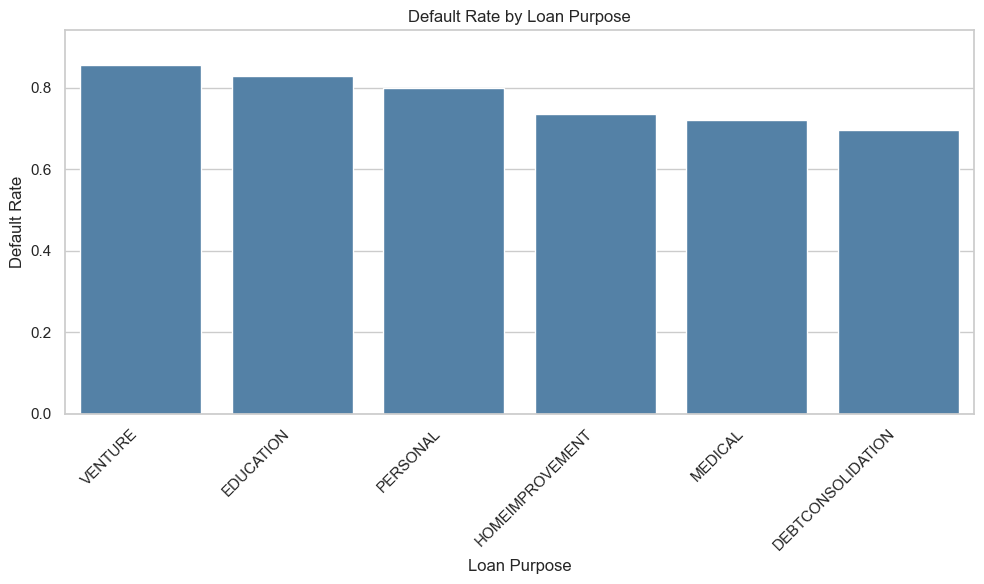

In [13]:
# PLot default rate by loan purpose

plt.figure(figsize=(10, 6))
sns.barplot(
    data=default_rate_by_purpose,
    x="loan_purpose",
    y="default_rate",
    color="steelblue"
)

plt.title("Default Rate by Loan Purpose")
plt.xlabel("Loan Purpose")
plt.ylabel("Default Rate")
plt.xticks(rotation=45, ha="right")  # rotate labels for readability[web:41][web:42]
plt.ylim(0, default_rate_by_purpose["default_rate"].max() * 1.1)

plt.tight_layout()
plt.show()

#### Create Bins for Specific Numeric Features 


In [14]:
# Age Bins

age_bins = [18, 25, 35, 50, 100]
age_labels = ["18_25", "26_35", "36_50", "50_plus"]

df["age_bucket"] = pd.cut(
    df["age"],
    bins=age_bins,
    labels=age_labels,
    right=True,
    include_lowest=True
)

In [15]:
# Credit Score FICO Bins 

fico_bins = [300, 579, 669, 739, 799, 850]
fico_labels = ["Poor", "Fair", "Good", "Very good", "Exceptional"]

df["credit_score_band"] = pd.cut(
    df["credit_score"],
    bins=fico_bins,
    labels=fico_labels,
    right=True,
    include_lowest=True
)

In [16]:
# Loan Percent to Income Bins

lpti_bins = [0, 0.36, 0.43, 0.50, float("inf")]
lpti_labels = ["Low / Strong", "Moderate / Acceptable",
               "High / Risky", "Excessive"]

df["loan_percent_to_income_band"] = pd.cut(
    df["loan_percent_to_income"],
    bins=lpti_bins,
    labels=lpti_labels,
    right=True,
    include_lowest=True
)

In [17]:
# Income Bins 

income_bins = [
    0,
    30000,
    60000,
    120000,
    250000,
    float("inf")
]
income_labels = [
    "Low (<30k)",
    "Lower-middle (30k–59,999)",
    "Middle (60k–119,999)",
    "Upper-middle (120k–249,999)",
    "High (250k+)"
]

df["income_band"] = pd.cut(
    df["income_capped"],
    bins=income_bins,
    labels=income_labels,
    right=True,
    include_lowest=True
)

In [18]:
# Loan Amount Bins 

loan_amt_bins = [
    0,
    5_000,
    25_000,
    100_000,
    500_000,
    1_000_000,
    5_000_000,
    float("inf")
]
loan_amt_labels = [
    "Micro / very small (0–5k)",
    "Small (5,001–25k)",
    "Lower-mid (25,001–100k)",
    "Upper-mid (100,001–500k)",
    "Large (500,001–1M)",
    "Very large / jumbo (1M–5M)",
    "Ultra-large (>5M)"
]

df["loan_amount_band"] = pd.cut(
    df["loan_amount"],
    bins=loan_amt_bins,
    labels=loan_amt_labels,
    right=True,
    include_lowest=True
)

In [19]:
def default_rate_by_feature(df, feature, target="default_flag"):
    stats = (
        df.groupby(feature, dropna=False)[target]
          .mean()
          .rename("default_rate")
          .reset_index()
    )
    return stats

In [20]:
display(df[["loan_repaid", "default_flag"]].head())
display(df["loan_repaid"].value_counts(normalize=True).rename("proportion"))
display(df["default_flag"].value_counts(normalize=True).rename("proportion"))

,loan_repaid,default_flag
0,1,0
1,0,1
2,1,0
3,1,0
4,1,0


loan_repaid
0   0.778
1   0.222
Name: proportion, dtype: float64

default_flag
1   0.778
0   0.222
Name: proportion, dtype: float64

In [29]:
def plot_default_rate_bar(df, feature, target="default_flag",
                          sort_desc=True, figsize=(8, 5),
                          palette="Blues"):
    stats = default_rate_by_feature(df, feature, target=target)
    if sort_desc:
        stats = stats.sort_values("default_rate", ascending=False)

    plt.figure(figsize=figsize)
    ax = sns.barplot(
        data=stats,
        x=feature,
        y="default_rate",
        hue=feature,
        palette=palette,
        dodge=False,
        legend=False,
    )

    plt.title(f"Default Rate by {feature}")
    plt.xlabel(feature.replace("_", " ").title())
    plt.ylabel("Default Rate")
    plt.xticks(rotation=45, ha="right")
    plt.ylim(0, stats["default_rate"].max() * 1.15)

    # Use the bar height itself, not an external list
    for patch in ax.patches:
        height = patch.get_height()
        x = patch.get_x() + patch.get_width() / 2

        ax.text(
            x,
            height + 0.02,
            f"{height:.2f}",          # or f"{height*100:.1f}%"
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold",
            color="black",
        )

    plt.tight_layout()
    plt.show()

    return stats

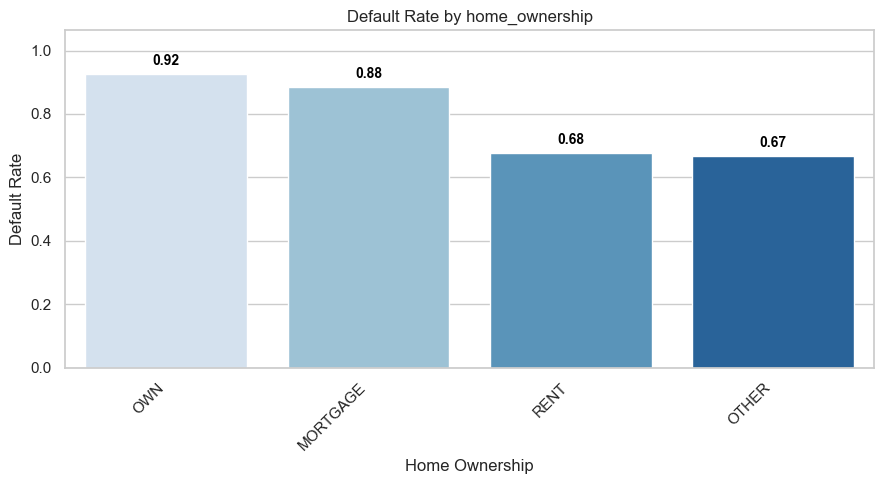

,home_ownership,default_rate,count
2,OWN,0.925,2951
0,MORTGAGE,0.884,18485
3,RENT,0.676,23439
1,OTHER,0.667,117


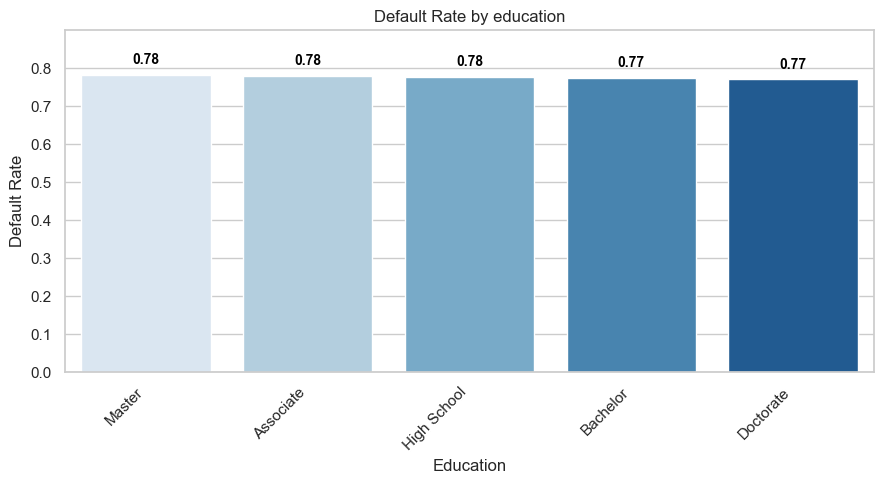

,education,default_rate,count
4,Master,0.782,6980
0,Associate,0.780,12026
3,High School,0.777,11969
1,Bachelor,0.775,13396
2,Doctorate,0.771,621


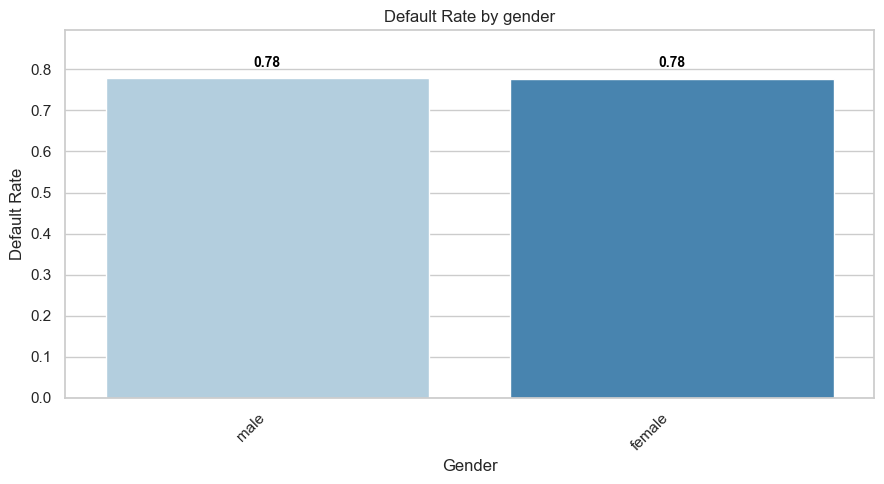

,gender,default_rate,count
1,male,0.778,24835
0,female,0.777,20157


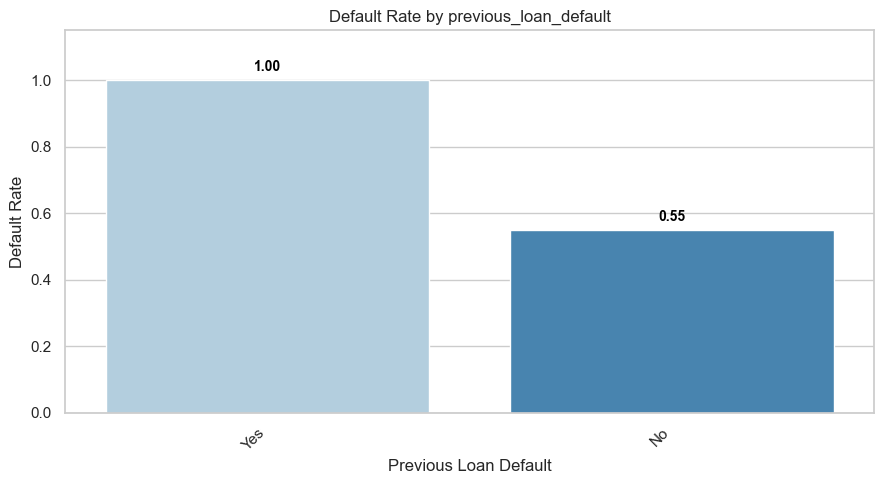

,previous_loan_default,default_rate,count
1,Yes,1.000,22856
0,No,0.548,22136


/var/folders/y2/97p_6_mn1ns3n6fh_thgm4780000gn/T/ipykernel_94678/2053575386.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(feature, dropna=False)[target]


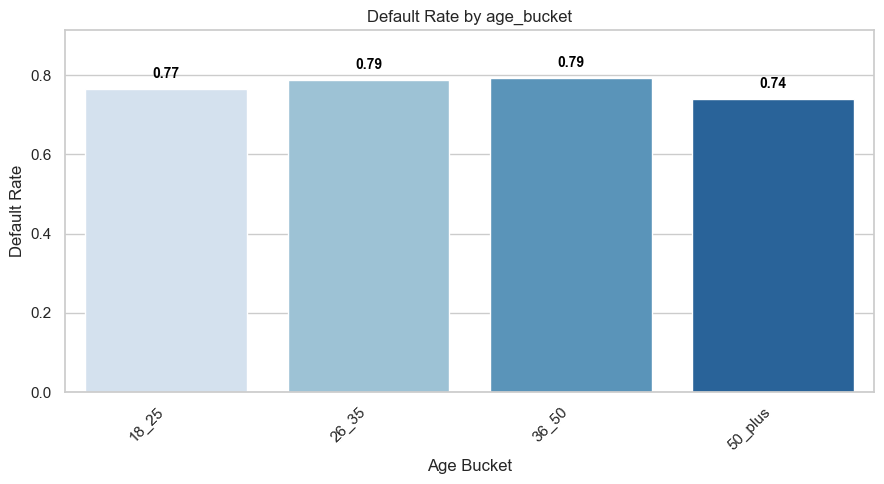

,age_bucket,default_rate,count
2,36_50,0.794,4158
1,26_35,0.787,20073
0,18_25,0.766,20441
3,50_plus,0.741,320


/var/folders/y2/97p_6_mn1ns3n6fh_thgm4780000gn/T/ipykernel_94678/2053575386.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(feature, dropna=False)[target]


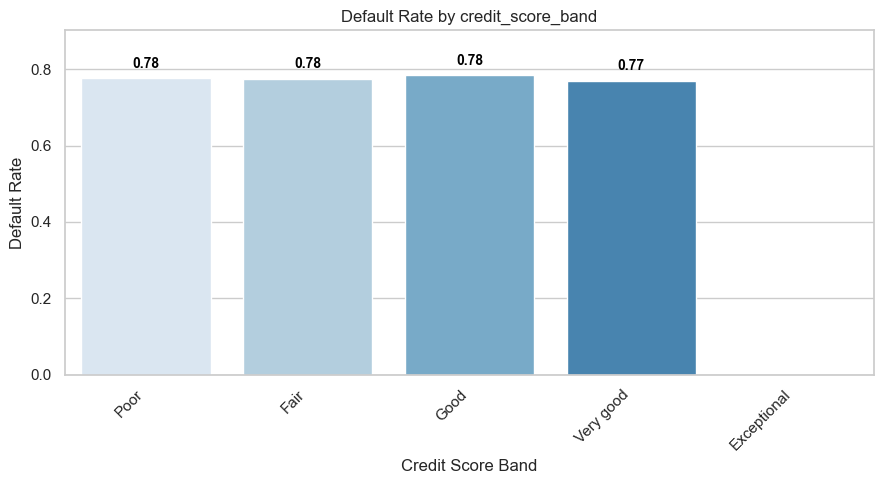

,credit_score_band,default_rate,count
2,Good,0.784,11194
0,Poor,0.777,6901
1,Fair,0.775,26806
3,Very good,0.769,91
4,Exceptional,NaN,0


/var/folders/y2/97p_6_mn1ns3n6fh_thgm4780000gn/T/ipykernel_94678/2053575386.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(feature, dropna=False)[target]


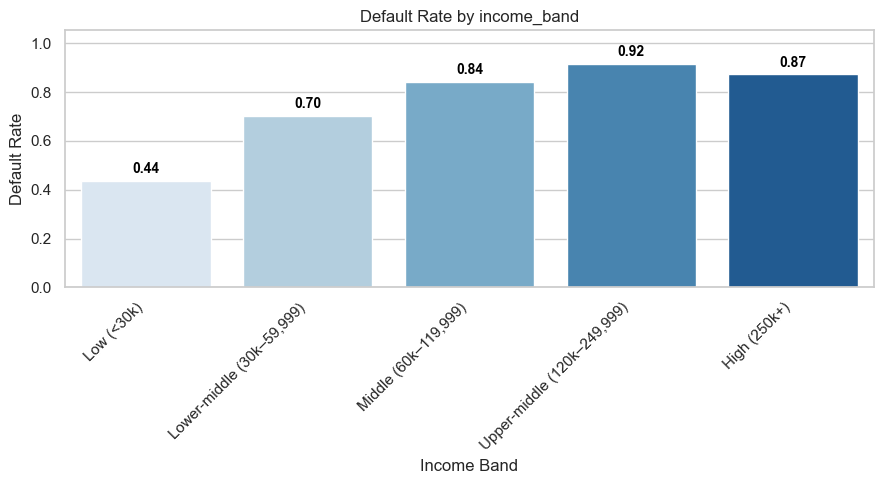

,income_band,default_rate,count
3,"Upper-middle (120k–249,999)",0.916,5780
4,High (250k+),0.872,572
2,"Middle (60k–119,999)",0.841,20355
1,"Lower-middle (30k–59,999)",0.703,15383
0,Low (<30k),0.438,2902


/var/folders/y2/97p_6_mn1ns3n6fh_thgm4780000gn/T/ipykernel_94678/2053575386.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(feature, dropna=False)[target]


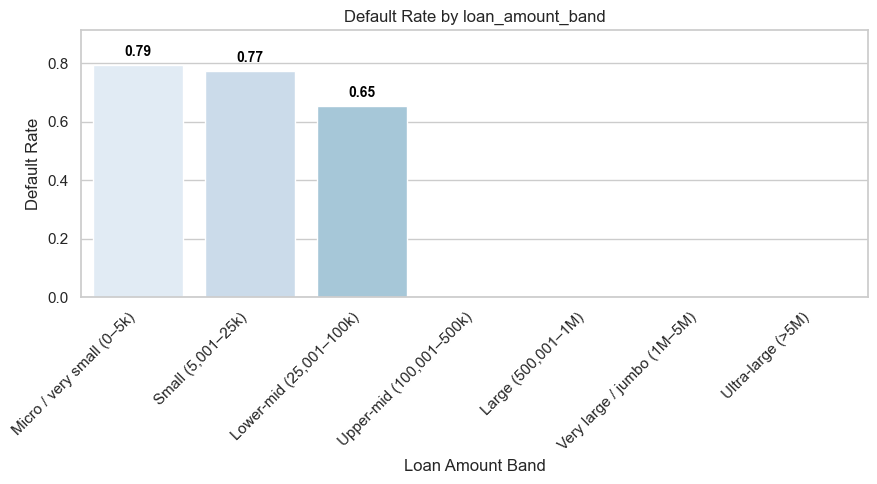

,loan_amount_band,default_rate,count
0,Micro / very small (0–5k),0.793,13128
1,"Small (5,001–25k)",0.774,31251
2,"Lower-mid (25,001–100k)",0.653,613
3,"Upper-mid (100,001–500k)",NaN,0
4,"Large (500,001–1M)",NaN,0
5,Very large / jumbo (1M–5M),NaN,0
6,Ultra-large (>5M),NaN,0


/var/folders/y2/97p_6_mn1ns3n6fh_thgm4780000gn/T/ipykernel_94678/2053575386.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(feature, dropna=False)[target]


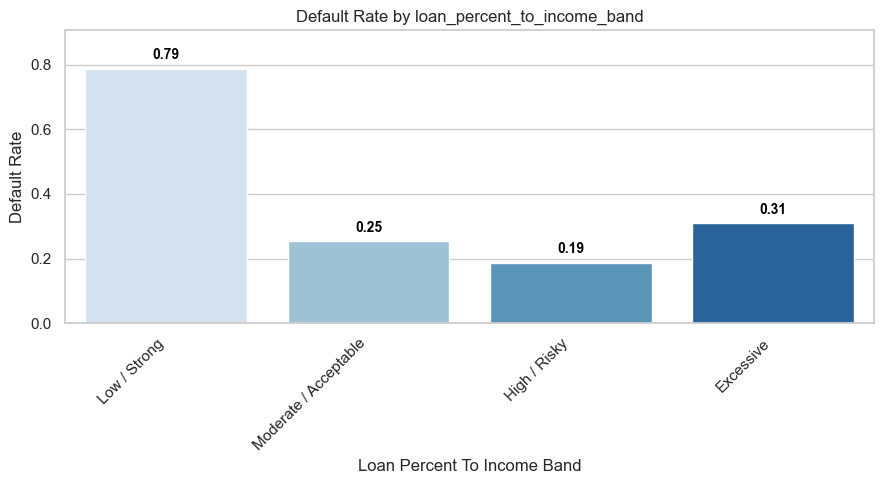

,loan_percent_to_income_band,default_rate,count
0,Low / Strong,0.789,44094
3,Excessive,0.309,55
1,Moderate / Acceptable,0.253,699
2,High / Risky,0.188,144


In [30]:
categorical_features = [
    "home_ownership",
    "education",
    "gender",
    "previous_loan_default",
    "age_bucket",
    "credit_score_band",
    "income_band",
    "loan_amount_band",
    "loan_percent_to_income_band"
]

for feature in categorical_features:
    stats = plot_default_rate_bar(df, feature, target="default_flag", figsize=(9, 5))
    display(stats)

### All default rate tables and barplots in this section use default_flag (1 = loan not repaid, 0 = loan repaid)

### In this dataset, higher incomes, lower DTI buckets, and homeowners exhibit higher observed default rates. This is counter to typical bank portfolios and likely reflects quirks of the synthetic dataset or approval rules rather than causal effects of income, DTI, or home ownership.